# NewsBot Intelligence System 2.0 — 01 Data Exploration

## Goal
Validate the preserved midterm sample and frame its business and methodological limits.

This notebook imports reusable project modules rather than duplicating implementation logic.

## Load and validate
The final uses the unchanged six-category midterm sample.

In [1]:
from src.data_processing.data_validator import DatasetValidator, load_news_dataset
df = load_news_dataset()
validation = DatasetValidator().validate(df)
validation.to_dict()

{'valid': True,
 'row_count': 1800,
 'columns': ['article_id',
  'title',
  'content',
  'full_text',
  'category',
  'authors',
  'source',
  'date',
  'link',
  'headline',
  'short_description'],
 'categories': {'BUSINESS': 300,
  'ENTERTAINMENT': 300,
  'POLITICS': 300,
  'SPORTS': 300,
  'TECH': 300,
  'WELLNESS': 300},
 'missing_by_column': {'headline': 0,
  'short_description': 0,
  'category': 0,
  'authors': 0,
  'date': 0,
  'full_text': 0},
 'duplicate_rows': 11,
 'invalid_dates': 0,
 'date_min': '2012-01-28',
 'date_max': '2022-09-14',
 'warnings': []}

## Coverage profile
Inspect category balance, date coverage, length, and duplicate signals before modelling.

In [2]:
import pandas as pd
pd.DataFrame({'rows':[len(df)], 'date_min':[str(df.date.min().date())], 'date_max':[str(df.date.max().date())], 'duplicate_rows':[df.duplicated().sum()], 'mean_words':[df.full_text.str.split().str.len().mean()]})

,rows,date_min,date_max,duplicate_rows,mean_words
0,1800,2012-01-28,2022-09-14,0,30.705556


## Category and date evidence
These figures are generated by the reproducible Phase 2 pipeline.

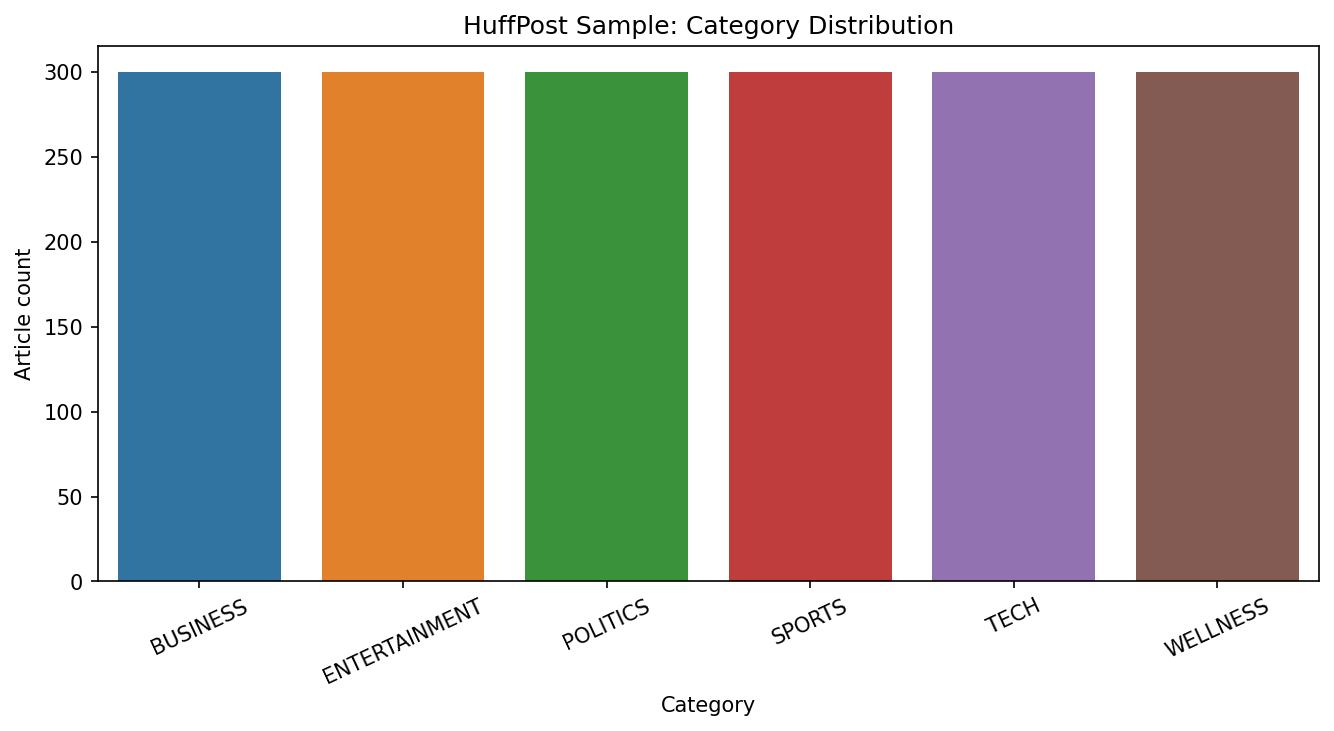

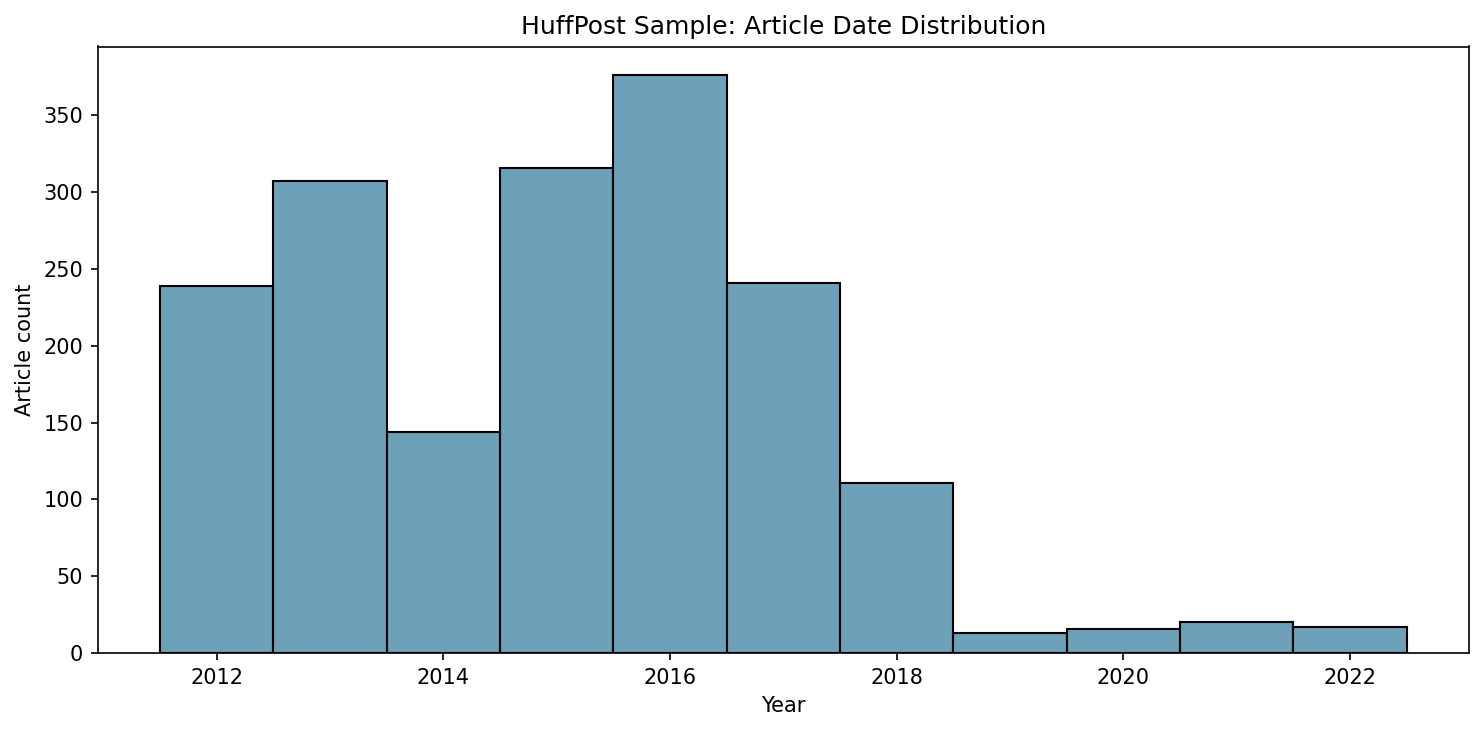

In [3]:
from pathlib import Path
from IPython.display import Image, display
figures = Path('data/results/figures')
display(Image(filename=str(figures / 'category_distribution.png')))
display(Image(filename=str(figures / 'date_distribution.png')))

## Sample records and framing
This is historical headline/description content, not full articles or live news.

In [4]:
df[['article_id','date','category','title','short_description']].sample(5, random_state=42).sort_values('date')

,article_id,date,category,title,short_description
943,944,2012-02-20,TECH,Samsung Electric LCD Business To Be Spun Off,With TVs becoming smart - linked to other devi...
162,163,2013-06-02,WELLNESS,Probiotics Could Help Protect Against Antibiot...,Antibiotics can sometimes come with a nasty si...
1591,1592,2015-04-05,SPORTS,Wisconsin Beats Kentucky To Advance To NCAA Ch...,Wisconsin ends Kentucky's pursuit of perfection.
1271,1272,2017-01-06,POLITICS,Elizabeth Warren Announces Re-Election Run For...,“I didn’t come to Washington to roll over and ...
869,870,2018-02-06,ENTERTAINMENT,"'The Cloverfield Paradox' Is A Waste, And Netf...",The sci-fi franchise's third installment had t...


## Limitations and ethics
The source corpus is historical and predominantly English. Confidence is not truth; sentiment, topics, named entities, translation, summaries, and semantic similarity can be wrong. Entity co-occurrence is not a proven real-world relationship. Internal corpus corroboration is not independent fact-checking.